In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error, r2_score)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge_IIoTset__DatasetFL.pdf
/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Readme.txt
/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Attack traffic/Uploading attack.pcap
/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Attack traffic/DDoS_ICMP_Flood_attack.csv
/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Attack traffic/DDoS_TCP_SYN_Flood_attack.csv
/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Attack traffic/MITM (ARP spoofing + DNS) Attack.pcap
/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Attack traffic/Uploading_attack.csv
/kaggle/input/datase

In [3]:
import os

df = pd.read_csv('/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv',
                 low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (2219201, 63)


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


In [4]:
# 1. Check basic info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Target column value counts ===")
print(df['Attack_type'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219201 entries, 0 to 2219200
Data columns (total 63 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   frame.time                 object 
 1   ip.src_host                object 
 2   ip.dst_host                object 
 3   arp.dst.proto_ipv4         object 
 4   arp.opcode                 float64
 5   arp.hw.size                float64
 6   arp.src.proto_ipv4         object 
 7   icmp.checksum              float64
 8   icmp.seq_le                float64
 9   icmp.transmit_timestamp    float64
 10  icmp.unused                float64
 11  http.file_data             object 
 12  http.content_length        float64
 13  http.request.uri.query     object 
 14  http.request.method        object 
 15  http.referer               object 
 16  http.request.full_uri      object 
 17  http.request.version       object 
 18  http.response              float64
 19  http.tls_port        

In [5]:
# 2. Drop columns that are not useful
drop_cols = ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4',
             'arp.dst.proto_ipv4', 'http.file_data', 'http.request.full_uri',
             'icmp.transmit_timestamp', 'http.request.uri.query', 'tcp.options',
             'tcp.payload', 'tcp.srcport', 'tcp.dstport', 'udp.port', 'mqtt.msg']

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 3. Drop rows with missing values
df.dropna(inplace=True)

# 4. Encode the target label
le = LabelEncoder()
df['Attack_label'] = le.fit_transform(df['Attack_type'])
print("Classes:", list(le.classes_))

# 5. Separate features and target
X = df.drop(columns=['Attack_type', 'Attack_label'])
y = df['Attack_label']

# 6. Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# 7. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFinal X shape:", X_scaled.shape)
print("Final y shape:", y.shape)

Classes: ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS']

Final X shape: (2219201, 39)
Final y shape: (2219201,)


In [6]:
# Reduce dataset size to avoid crash (take 100,000 random rows)
from sklearn.utils import resample

X_scaled_small, y_small = resample(X_scaled, y, 
                                    n_samples=100000, 
                                    random_state=42)

print("Reduced X shape:", X_scaled_small.shape)
print("Reduced y shape:", y_small.shape)

# Replace originals with smaller version
X_scaled = X_scaled_small
y = y_small

Reduced X shape: (100000, 39)
Reduced y shape: (100000,)


Variance explained by 2 components: 25.38 %


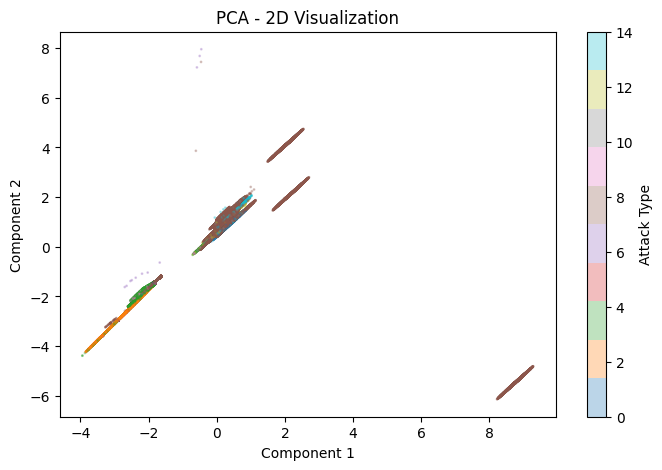

Shape after PCA (39 components): (100000, 39)


In [8]:
# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by 2 components:", 
      round(sum(pca.explained_variance_ratio_)*100, 2), "%")

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.3, s=1)
plt.title("PCA - 2D Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Attack Type')
plt.show()

# Use 39 components for ML models (max possible)
pca_full = PCA(n_components=39)
X_pca_full = pca_full.fit_transform(X_scaled)
print("Shape after PCA (39 components):", X_pca_full.shape)

In [9]:
svd = TruncatedSVD(n_components=39)
X_svd = svd.fit_transform(X_scaled)

print("Variance explained by SVD:", 
      round(sum(svd.explained_variance_ratio_)*100, 2), "%")
print("Shape after SVD:", X_svd.shape)

Variance explained by SVD: 100.0 %
Shape after SVD: (100000, 39)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_full, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (80000, 39)
Test size: (20000, 39)


In [11]:
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", round(accuracy_score(y_test, y_pred_knn)*100, 2), "%")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

Training KNN...
KNN Accuracy: 88.77 %
                       precision    recall  f1-score   support

             Backdoor       0.59      0.70      0.64       226
            DDoS_HTTP       0.51      0.29      0.37       449
            DDoS_ICMP       0.99      1.00      1.00      1059
             DDoS_TCP       0.70      0.90      0.79       440
             DDoS_UDP       1.00      1.00      1.00      1102
       Fingerprinting       1.00      0.09      0.17        11
                 MITM       0.00      0.00      0.00        11
               Normal       0.90      0.99      0.94     14537
             Password       0.49      0.08      0.14       463
        Port_Scanning       0.47      0.22      0.30       201
           Ransomware       0.60      0.36      0.45        97
        SQL_injection       0.54      0.11      0.18       459
            Uploading       0.66      0.13      0.21       335
Vulnerability_scanner       0.89      0.73      0.80       461
                

In [12]:
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
r2  = r2_score(y_test, y_pred_lr)
print(f"MSE: {round(mse,4)},  R² Score: {round(r2,4)}")

# Convert to class labels for accuracy
y_pred_lr_class = np.round(y_pred_lr).astype(int).clip(0, len(le.classes_)-1)
print("Accuracy (rounded):", round(accuracy_score(y_test, y_pred_lr_class)*100, 2), "%")

Training Linear Regression...
MSE: 3.572,  R² Score: 0.3539
Accuracy (rounded): 72.84 %


In [13]:
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log)*100, 2), "%")
print(classification_report(y_test, y_pred_log, target_names=le.classes_))

Training Logistic Regression...
Logistic Regression Accuracy: 88.55 %
                       precision    recall  f1-score   support

             Backdoor       0.30      0.21      0.24       226
            DDoS_HTTP       0.54      0.25      0.34       449
            DDoS_ICMP       0.99      1.00      1.00      1059
             DDoS_TCP       0.75      0.97      0.84       440
             DDoS_UDP       1.00      0.98      0.99      1102
       Fingerprinting       0.00      0.00      0.00        11
                 MITM       0.00      0.00      0.00        11
               Normal       0.89      1.00      0.94     14537
             Password       0.95      0.05      0.09       463
        Port_Scanning       0.93      0.37      0.53       201
           Ransomware       0.00      0.00      0.00        97
        SQL_injection       0.45      0.07      0.12       459
            Uploading       0.77      0.06      0.11       335
Vulnerability_scanner       0.85      0.75     

In [14]:
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt)*100, 2), "%")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Training Decision Tree...
Decision Tree Accuracy: 89.94 %
                       precision    recall  f1-score   support

             Backdoor       0.74      0.42      0.54       226
            DDoS_HTTP       0.75      0.30      0.43       449
            DDoS_ICMP       1.00      1.00      1.00      1059
             DDoS_TCP       0.77      0.96      0.86       440
             DDoS_UDP       1.00      1.00      1.00      1102
       Fingerprinting       0.75      0.27      0.40        11
                 MITM       0.00      0.00      0.00        11
               Normal       0.89      1.00      0.94     14537
             Password       0.86      0.12      0.21       463
        Port_Scanning       0.76      0.43      0.55       201
           Ransomware       0.86      0.32      0.47        97
        SQL_injection       0.96      0.14      0.24       459
            Uploading       0.64      0.15      0.25       335
Vulnerability_scanner       0.95      0.78      0.86       

In [15]:
print("Training Random Forest (takes 2-3 mins)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Training Random Forest (takes 2-3 mins)...
Random Forest Accuracy: 90.01 %
                       precision    recall  f1-score   support

             Backdoor       0.72      0.43      0.54       226
            DDoS_HTTP       0.92      0.29      0.44       449
            DDoS_ICMP       0.99      1.00      1.00      1059
             DDoS_TCP       0.77      1.00      0.87       440
             DDoS_UDP       1.00      1.00      1.00      1102
       Fingerprinting       0.00      0.00      0.00        11
                 MITM       0.00      0.00      0.00        11
               Normal       0.89      1.00      0.94     14537
             Password       0.95      0.08      0.15       463
        Port_Scanning       0.92      0.40      0.56       201
           Ransomware       0.97      0.32      0.48        97
        SQL_injection       0.95      0.12      0.22       459
            Uploading       0.79      0.14      0.23       335
Vulnerability_scanner       0.89      0.82

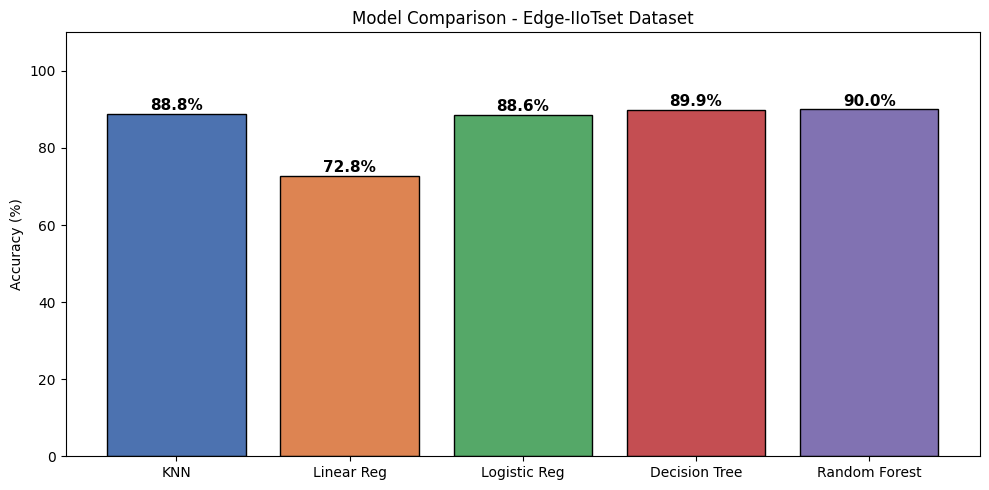


===== FINAL RESULTS =====
KNN                  88.77%
Linear Reg           72.84%
Logistic Reg         88.55%
Decision Tree        89.94%
Random Forest        90.01%


In [16]:
models     = ['KNN', 'Linear Reg', 'Logistic Reg', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_lr_class),
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(10, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
bars = plt.bar(models, [a*100 for a in accuracies], color=colors, edgecolor='black')
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Edge-IIoTset Dataset")
plt.ylim(0, 110)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc*100:.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print("\n===== FINAL RESULTS =====")
for m, a in zip(models, accuracies):
    print(f"{m:<20} {round(a*100, 2)}%")